# House Clustering using K-Means Clustering Techniques
### Mini Project - Machine Learning with Python

## Introduction
In this project, I have applied K-Means clustering to group houses based on different features such as income, population, and housing characteristics. The aim is to identify patterns in the dataset and understand how similar houses can be grouped together.

In [6]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# Load Dataset
housing = fetch_california_housing()
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


## Data Preprocessing
Before applying clustering, the data is scaled using StandardScaler. This ensures that all features contribute equally to the model and prevents bias due to different value ranges.

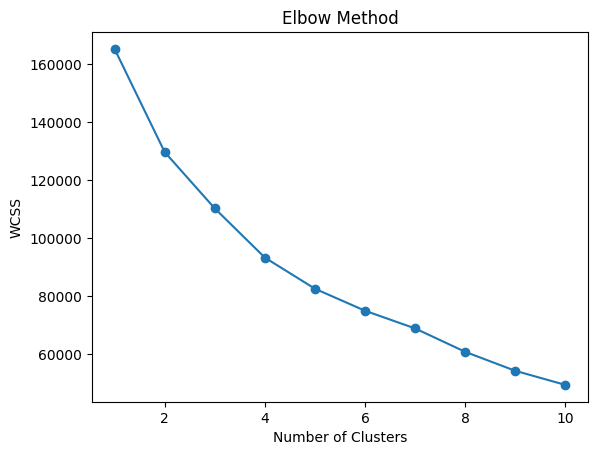

In [7]:
from sklearn.cluster import KMeans

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(housing_df)

# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

# Plot
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(scaled_data)

housing_df['Cluster'] = cluster_labels

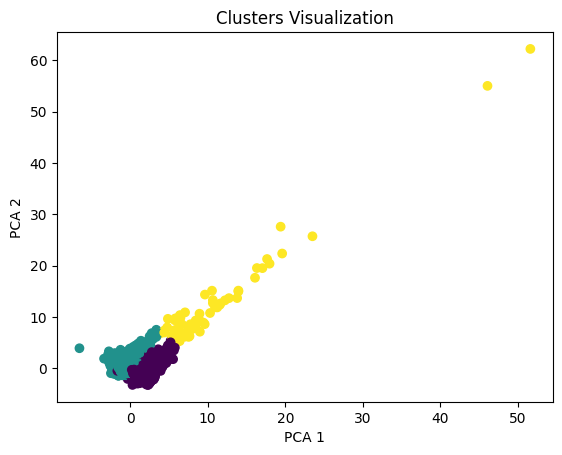

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:,0], pca_data[:,1], c=cluster_labels)
plt.title("Clusters Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [10]:
cluster_summary = housing_df.groupby('Cluster').mean()
cluster_summary

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
Cluster,,,,,,,,
0,3.805078,29.029667,5.503181,1.081928,1287.181017,3.037686,37.950337,-121.729971
1,3.921265,28.420695,5.206308,1.071632,1532.655718,3.098150,33.942695,-118.009083
2,3.372851,18.697368,31.977939,6.703742,296.171053,2.496145,37.659079,-119.373289


## Observation
From the results, it can be observed that different clusters represent different types of housing groups. One cluster shows higher average number of rooms and lower population, indicating larger houses, while another cluster represents more densely populated areas.

## Conclusion
In this project, K-Means clustering was successfully used to group houses based on their features. The model was able to identify meaningful patterns in the dataset, which can be useful for understanding housing trends.

## Source
Dataset: California Housing Dataset  
Source: Scikit-learn Library  
Reference: Kaggle - Clustering with K-Means